**VIX in the rough Bergomi model**

Convention is different. The parameter $\eta$ in the paper must be 
replaced with $\eta \sqrt{2H}$

Given a kernel function $K(\cdot)$, consider the SDE for the instantaneous 
forward variance curve model
$$
    d\xi_t^u = \xi_t^u K(u,t) \, dW_t
$$
or equivalently, for all $u \geq T$,
$$
    \xi_T^u = \xi_0^u \exp \left\{ Z_T^u \right\}
$$
where 
$$
    Z_T^u = -\frac{1}{2}\int_0^T K(u,t)^2 \, dt + \int_0^T K(u,t) \, dW_t.
$$

We approximte the 

$$
    \text{VIX}_T^2 
    = \frac{1}{\Delta} \int_{T}^{T+\Delta} \xi_T^u \, du
    = \frac{1}{\Delta} \int_{T}^{T+\Delta} \xi_0^u \exp \{Z_T^u\} \, du
$$

with a lognormal proxy

$$
    \text{VIX}_{T,P}^2 = \mathbb{E}[\text{VIX}_T^2]
    \exp \left\{\frac{1}{\Delta} \int_{T}^{T+\Delta} \xi_0^u Z_T^u 
    \frac{du}{\mathbb{E}[\text{VIX}_T^2]}\right\}
$$

where the fair price of a VIX squared futures contract is given by

$$
    \mathbb{E}[\text{VIX}_T^2] = \frac{1}{\Delta} 
    \int_{T}^{T+\Delta} \xi_0^u du.
$$

We have that $\log \text{VIX}_{T,P}^2$ is normal with mean

$$
    \mu_{P} = 
    \log \mathbb{E}[\text{VIX}_T^2] -
    \frac12 \int_0^T \left(\frac1\Delta 
    \int_{T}^{T+\Delta} \xi_0^u K(u,t)^2 \frac{du}{\mathbb{E}[\text{VIX}_T^2]} \right) \, dt
$$

and variance

$$
    \sigma_{P}^2 = 
    \int_0^T \left(\frac1\Delta 
    \int_{T}^{T+\Delta} \xi_0^u K(u,t) \frac{du}{\mathbb{E}[\text{VIX}_T^2]} \right)^2 \, dt
$$

---

We approximate the VIX option price by
$$
    \mathbb{E}[\varphi(\text{VIX}_{T}^2)] \approx
    \mathbb{E}[\varphi(\text{VIX}_{T,P}^2)]
    + \sum_{i=1}^{3} \gamma_i \, \partial_{\varepsilon}\left.\mathbb{E}\left[\varphi(\text{VIX}_{T,P}^2 \, e^{\varepsilon})\right]\right|_{\varepsilon=0}
$$

- The zeroth order approximation corresponds to a Black-Scholes price
while the other terms are corrections based on Black-Scholes Greeks (delta, gamma, speed).

- The coefficients $\gamma_i$ are deterministic integrals depending on the kernel.

# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
from rbergomi import RoughBergomiModel, get_params_rbergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import relative_error

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

# Global settings
SEED = 1234
COLORS = sns.color_palette("tab10")
SAVEFIG = True

In [3]:
# simulation parameters
n_disc = 300
n_mc = 1 * 10**6
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0}

# Single case

## VIX implied volatility

Plot VIX smiles as a function of $\log(K/F)$

In [13]:
id = 2
params, xi0 = get_params_rbergomi(id=id, opt="single")
rbergomi = RoughBergomiModel(xi0=xi0, params=params)
rbergomi

RoughBergomiModel with parameters:
H=0.23, eta=1.5039079527799508, rho=-0.5, s0=1.0

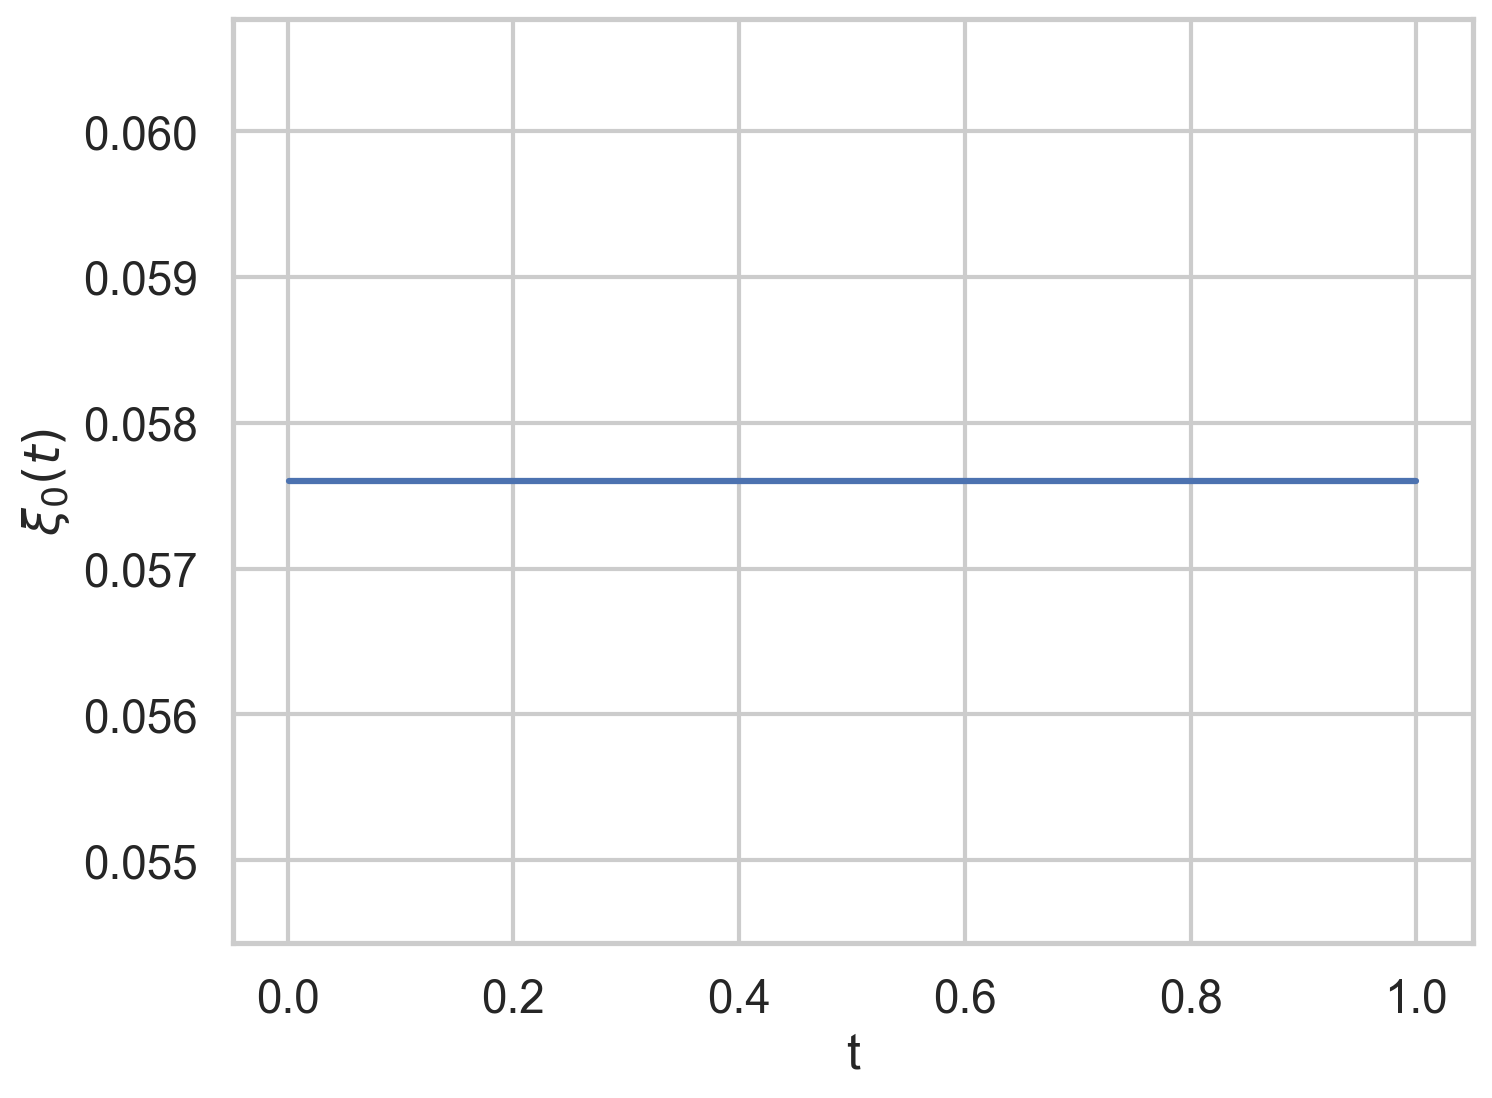

In [14]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, rbergomi.xi0(ts))
ax.set_xlabel("t")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [15]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)

In [16]:
# VIX implied volatilities from Monte Carlo
impvol_vix = {
    month: rbergomi.implied_vol_vix(k=ks, T=T, n_disc=n_disc, n_mc=n_mc, seed=SEED)
    for month, T in mats.items()
}

In [17]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: rbergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [18]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: rbergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

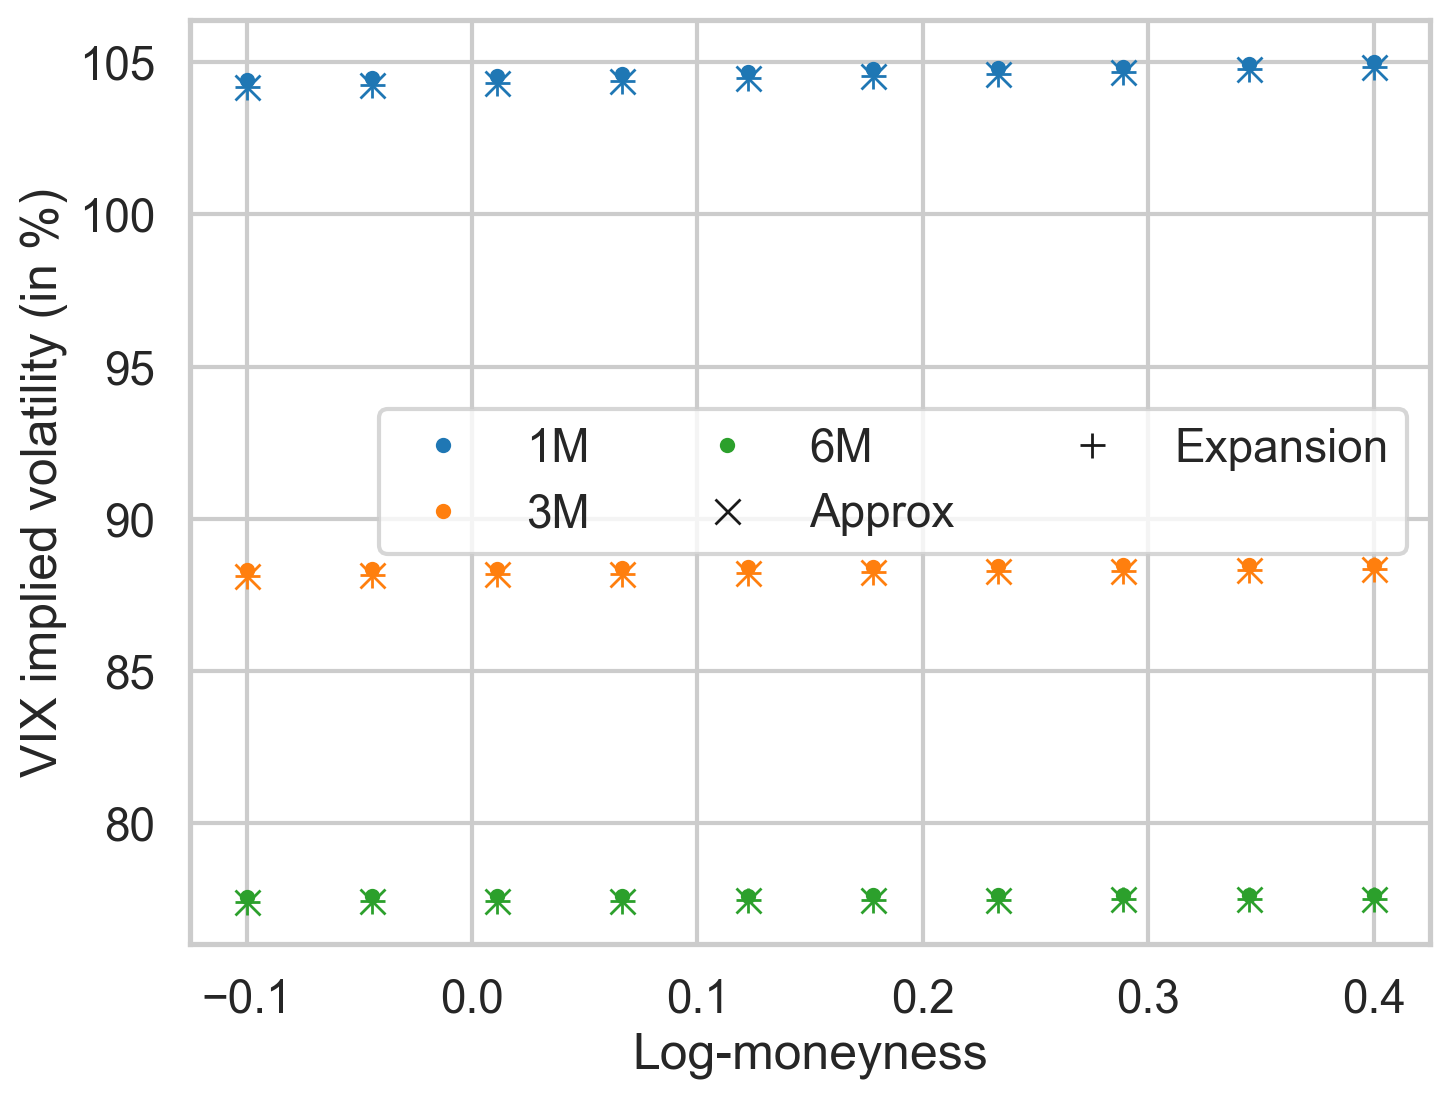

In [ ]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("VIX implied volatility (in %)")
ax.legend(loc="center right", ncol=3)
if SAVEFIG:
    fig.savefig(f"figures/vix_rbergomi_{id}.pdf", bbox_inches="tight")
plt.show()

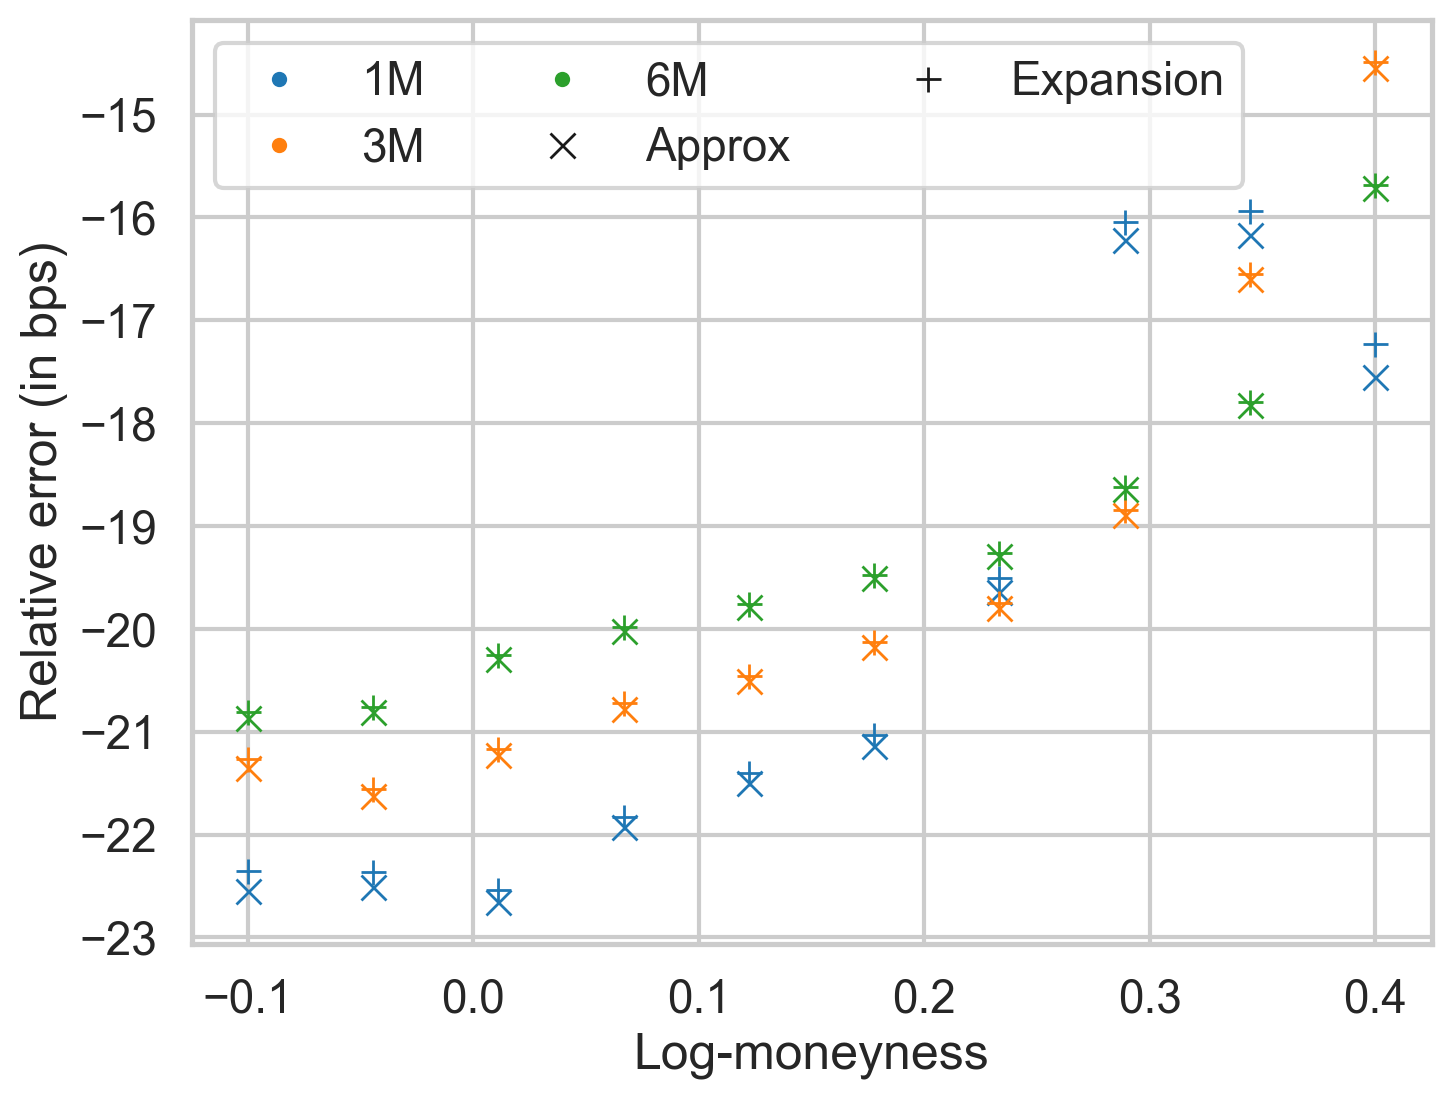

In [ ]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix[month], impvol_vix_approx[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix[month], impvol_vix_expansion[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e4 * rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, 1e4 * rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Relative error (in bps)")
ax.legend(loc="best", ncol=3)
if SAVEFIG:
    fig.savefig(f"figures/vix_rbergomi_error_{id}.pdf", bbox_inches="tight")
plt.show()

# Mixed case

$
\xi_T^u = \xi_0^u \left(
    \lambda \exp\{Z_{T,1}^{u}\} + (1-\lambda) \exp\{Z_{T,2}^{u}\}
\right)
$
where

- $Z_{T,i}^{u} = -\frac12 \int_0^T K_i(u,t)^2 \, dt + \int_0^T K_i(u,t) \, dW_t$,

## VIX implied volatility

Plot VIX smiles as a function of $k=\log(K/F)$

In [14]:
id = 2
params, xi0, lbd, eta_2 = get_params_rbergomi(id=id, opt="mixed")
rbergomi = RoughBergomiModel(xi0=xi0, params=params)
rbergomi

RoughBergomiModel with parameters:
H=0.23, eta=2.9488391230979425, rho=-0.5, s0=1.0

In [15]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)
n_quad = 80

In [16]:
# VIX implied volatilities via Monte Carlo
impvol_vix_mixed = {
    month: rbergomi.implied_vol_vix(
        lbd=lbd, eta_2=eta_2, k=ks, T=T, n_disc=n_disc, n_mc=n_mc, seed=SEED
    )
    for month, T in mats.items()
}

In [17]:
# VIX implied volatilities via weak approximation
impvol_vix_mixed_approx = {
    month: np.asarray(
        rbergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=eta_2, k=ks, T=T, order=3, n_quad=n_quad
        )
    )
    for month, T in mats.items()
}

In [21]:
# VIX implied volatilities via expansion formula
j_mixed = 1
implied_vol_vix_expansion = {
    month: np.array(
        [
            rbergomi.implied_vol_vix_expansion_mixed(
                k=k,
                T=T,
                lbd=lbd,
                volvol_2=eta_2,
                n_quad=n_quad,
                n_trunc_herm=10,
                j=j_mixed,
            )
            for k in ks
        ]
    )
    for month, T in mats.items()
}

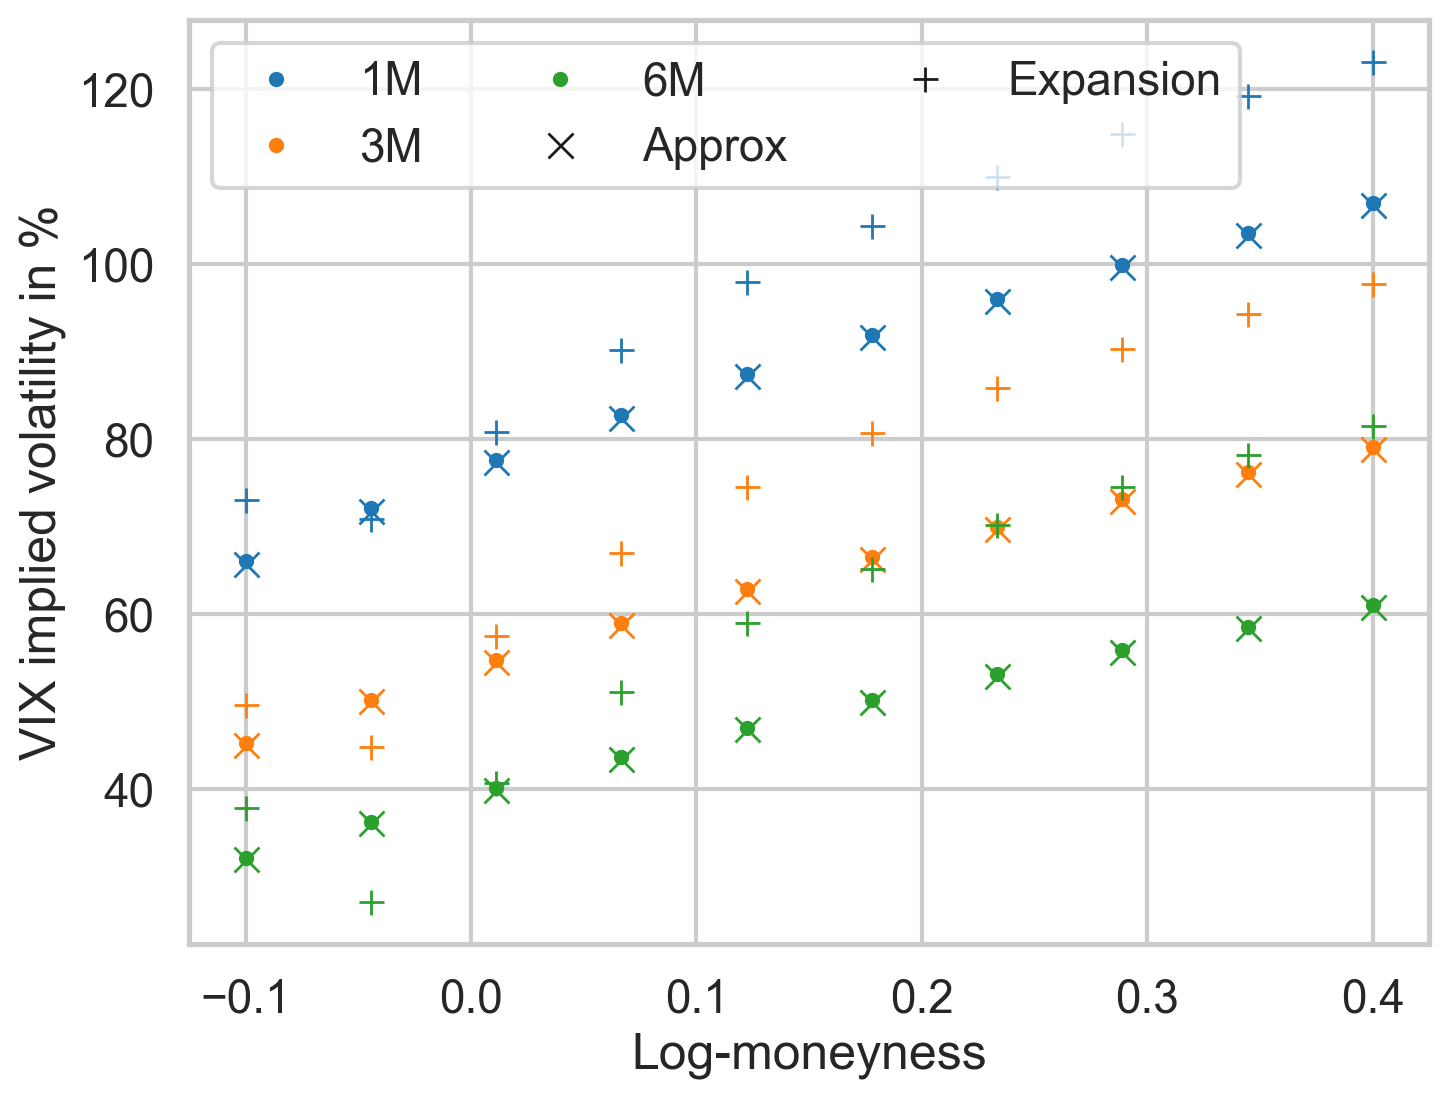

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    # True VIX implied volatilities
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    # Weak approximation
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[month],
        "x",
        color=COLORS[i],
    )
    # Expansion formula
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[month],
        "+",
        color=COLORS[i],
    )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
if SAVEFIG:
    fig.savefig(f"figures/vix_rbergomi_mixed_{id}_j_{j_mixed}.pdf", bbox_inches="tight")
plt.show()

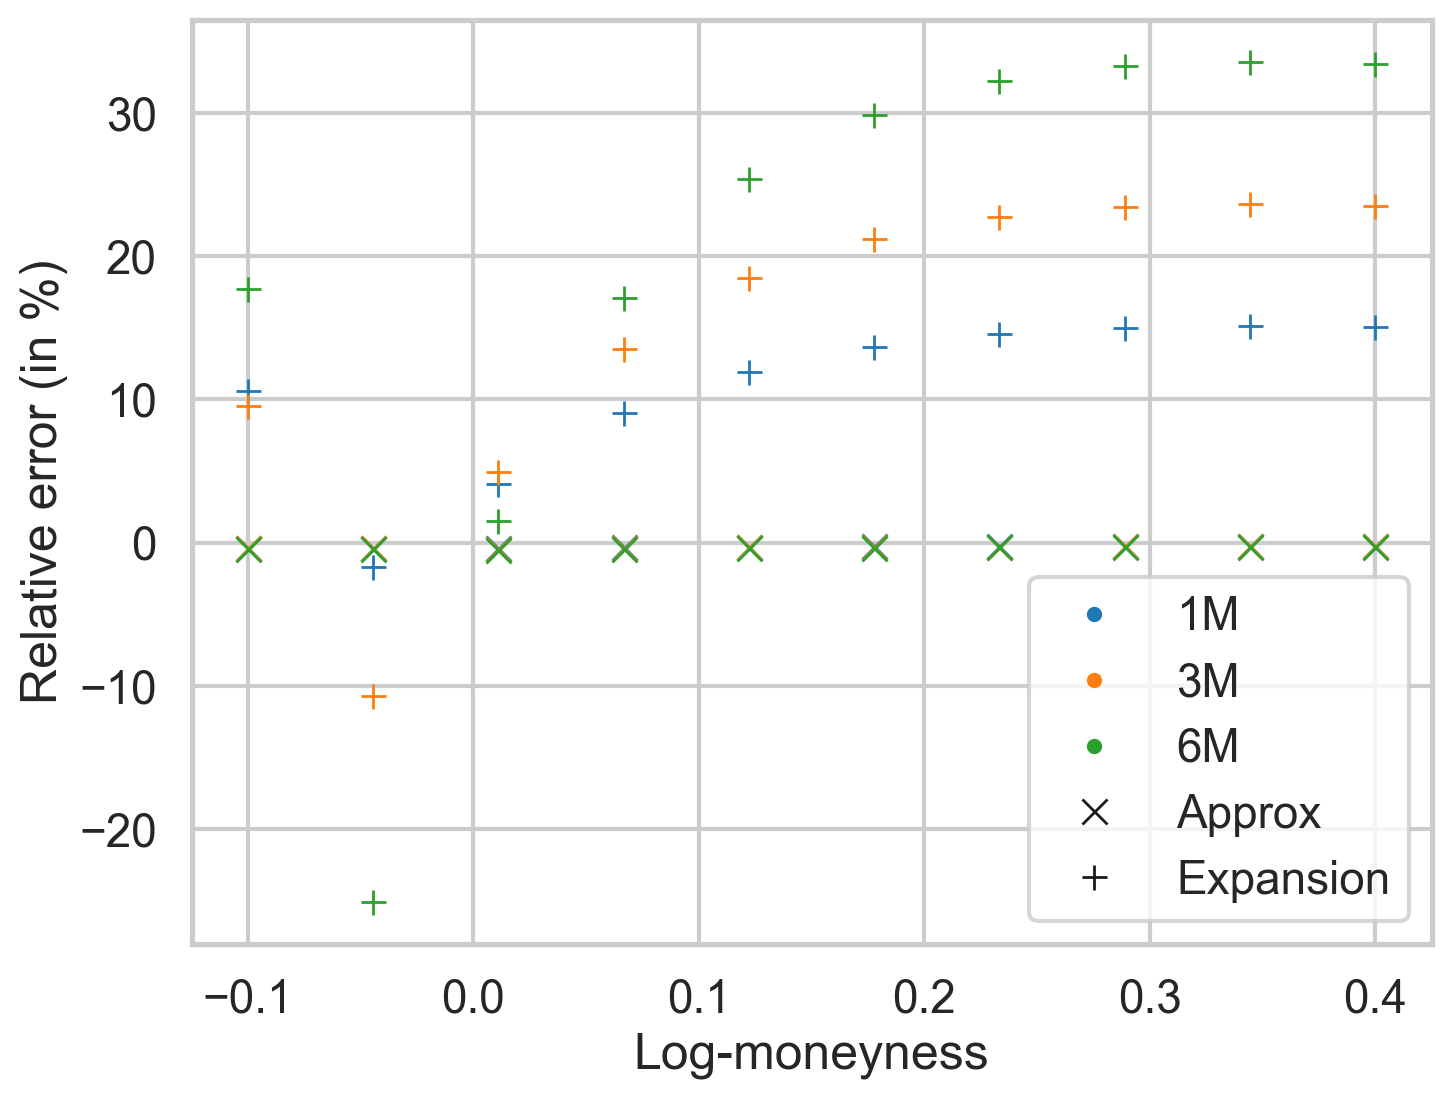

In [23]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_mixed[month], impvol_vix_mixed_approx[month])
    for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_mixed[month], implied_vol_vix_expansion[month])
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e2 * rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, 1e2 * rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Relative error (in %)")
ax.legend(loc="best")
if SAVEFIG:
    fig.savefig(
        f"figures/vix_rbergomi_error_mixed{id}_j_{j_mixed}.pdf", bbox_inches="tight"
    )
plt.show()